# Analisis Exploratorio de Datos (EDA)
## Prediccion de Autismo - Dataset Multimodal de Imagenes MRI

---

**Objetivo:** Realizar un analisis exploratorio exhaustivo del dataset de imagenes de resonancia magnetica cerebral para la clasificacion binaria de Trastorno del Espectro Autista (TEA vs. NonAutism), identificando caracteristicas estadisticas, distribuciones, calidad de datos y hallazgos clave que guien el preprocesamiento y el modelado.

**Clases:**
- `Autism`    Imagenes de pacientes con diagnostico de TEA
- `NonAutism` Imagenes de pacientes sin diagnostico (controles sanos)

**Estructura del Dataset:**
- Cada paciente tiene **3 cortes** de resonancia magnetica: `axial`, `coronal`, `sagittal`
- Los datos estan almacenados en un archivo **Parquet** con imagenes en formato `{'bytes': b'...'}`
- La division DEBE realizarse por `patient_id` para evitar **data leakage**

**Columnas del dataset:**
- `image`      : dict `{'bytes': PNG_bytes}` con la imagen codificada
- `image_type` : tipo de corte (`axial`, `coronal`, `sagittal`)
- `label`      : clase (`Autism` / `NonAutism`)
- `caption`    : descripcion textual del paciente
- `patient_id` : identificador unico del paciente

---

## 1. Importacion de Librerias

In [1]:
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 12,
})

PALETTE = {
    'autism'    : '#E63946',
    'control'   : '#2A9D8F',
    'axial'     : '#457B9D',
    'coronal'   : '#F4A261',
    'sagittal'  : '#8338EC',
    'bg_dark'   : '#1D3557',
    'neutral'   : '#A8DADC',
}

# Nombres de columnas del dataset
PATIENT_ID_COL = 'patient_id'
LABEL_COL      = 'label'
SLICE_TYPE_COL = 'image_type'
IMAGE_COL      = 'image'
CAPTION_COL    = 'caption'

SLICE_TYPES  = ['axial', 'coronal', 'sagittal']
CLASS_NAMES  = ['Autism', 'NonAutism']
CLASS_COLORS = {'Autism': PALETTE['autism'], 'NonAutism': PALETTE['control']}

print('Librerias importadas correctamente.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   PIL    : {Image.__version__}')

Librerias importadas correctamente.
   NumPy  : 2.4.4
   Pandas : 3.0.2
   PIL    : 12.2.0


---
## 2. Carga del Dataset Parquet

In [2]:
DATA_PATH = Path('../data/data.parquet')

print(f'Cargando dataset desde: {DATA_PATH}')
df_raw = pd.read_parquet(DATA_PATH)

print(f'\nDataset cargado exitosamente.')
print(f'   Filas totales : {len(df_raw):,}')
print(f'   Columnas      : {list(df_raw.columns)}')
print(f'   Tipos de dato :')
for col in df_raw.columns:
    print(f'      {col:<20} -> {df_raw[col].dtype}')

print(f'\nPrimeras 5 filas:')
df_raw.head()

Cargando dataset desde: ..\data\data.parquet

Dataset cargado exitosamente.
   Filas totales : 5,835
   Columnas      : ['image', 'image_type', 'label', 'caption', 'patient_id']
   Tipos de dato :
      image                -> object
      image_type           -> str
      label                -> str
      caption              -> str
      patient_id           -> str

Primeras 5 filas:


,image,image_type,label,caption,patient_id
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,axial,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,coronal,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,sagittal,Autism,A 48-year-old male with an FIQ score of 131 an...,ABIDEII-BNI_1_29006
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,axial,Autism,A 41-year-old male right-handed patient with a...,ABIDEII-BNI_1_29007
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,coronal,Autism,A 41-year-old male right-handed patient with a...,ABIDEII-BNI_1_29007


In [3]:
# Inspeccion de columnas — omite tipos no hasheables (dicts, arrays)
print('=== Informacion General del Dataset ===')
print(df_raw.info())

print('\n=== Valores unicos por columna ===')
for col in df_raw.columns:
    try:
        n_unique = df_raw[col].nunique()
        if n_unique <= 30:
            print(f'  {col:<25} -> {n_unique} unicos: {df_raw[col].unique().tolist()}')
        else:
            print(f'  {col:<25} -> {n_unique} unicos')
    except TypeError:
        sample_val = df_raw[col].iloc[0]
        print(f'  {col:<25} -> [no hasheable] tipo={type(sample_val).__name__}, '
              f'muestra={str(sample_val)[:60]}...')

=== Informacion General del Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 5835 entries, 0 to 5834
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5835 non-null   object
 1   image_type  5835 non-null   str   
 2   label       5835 non-null   str   
 3   caption     5835 non-null   str   
 4   patient_id  5835 non-null   str   
dtypes: object(1), str(4)
memory usage: 959.6+ KB
None

=== Valores unicos por columna ===
  image                     -> [no hasheable] tipo=dict, muestra={'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\...
  image_type                -> 3 unicos: ['axial', 'coronal', 'sagittal']
  label                     -> 2 unicos: ['Autism', 'NonAutism']
  caption                   -> 1941 unicos
  patient_id                -> 1945 unicos


In [4]:
# Extraer bytes de la columna image (formato HuggingFace: dict {'bytes': b'...'})
df = df_raw.copy()
df['image_bytes'] = df[IMAGE_COL].apply(lambda x: x['bytes'] if isinstance(x, dict) else x)

print('Columna image_bytes creada correctamente.')
print(f'Tipo de dato en image_bytes : {type(df["image_bytes"].iloc[0]).__name__}')
print(f'Longitud bytes muestra (fila 0): {len(df["image_bytes"].iloc[0]):,} bytes')
print(f'\nShape final del DataFrame de trabajo: {df.shape}')
df[[PATIENT_ID_COL, LABEL_COL, SLICE_TYPE_COL, CAPTION_COL]].head()

Columna image_bytes creada correctamente.
Tipo de dato en image_bytes : bytes
Longitud bytes muestra (fila 0): 39,208 bytes

Shape final del DataFrame de trabajo: (5835, 6)


,patient_id,label,image_type,caption
0,ABIDEII-BNI_1_29006,Autism,axial,A 48-year-old male with an FIQ score of 131 an...
1,ABIDEII-BNI_1_29006,Autism,coronal,A 48-year-old male with an FIQ score of 131 an...
2,ABIDEII-BNI_1_29006,Autism,sagittal,A 48-year-old male with an FIQ score of 131 an...
3,ABIDEII-BNI_1_29007,Autism,axial,A 41-year-old male right-handed patient with a...
4,ABIDEII-BNI_1_29007,Autism,coronal,A 41-year-old male right-handed patient with a...


---
## 3. Analisis de Pacientes y Estructura del Dataset

In [5]:
n_total_rows         = len(df)
n_patients           = df[PATIENT_ID_COL].nunique()
n_slices_per_patient = df.groupby(PATIENT_ID_COL).size()

print('='*52)
print('          ESTRUCTURA DEL DATASET')
print('='*52)
print(f'  Total de filas (registros)  : {n_total_rows:>8,}')
print(f'  Total de pacientes unicos   : {n_patients:>8,}')
print(f'  Cortes por paciente (media) : {n_slices_per_patient.mean():>8.2f}')
print(f'  Cortes por paciente (min)   : {n_slices_per_patient.min():>8,}')
print(f'  Cortes por paciente (max)   : {n_slices_per_patient.max():>8,}')
print('='*52)

slice_counts = df[SLICE_TYPE_COL].value_counts()
print(f'\nDistribucion de cortes por tipo:')
for st, cnt in slice_counts.items():
    print(f'   {st:<12} -> {cnt:,} imagenes')

pivot      = df.groupby([PATIENT_ID_COL, SLICE_TYPE_COL]).size().unstack(fill_value=0)
incomplete = pivot[(pivot == 0).any(axis=1)]
print(f'\nPacientes con cortes faltantes: {len(incomplete):,}')
if len(incomplete) > 0:
    print(incomplete.head(10))

          ESTRUCTURA DEL DATASET
  Total de filas (registros)  :    5,835
  Total de pacientes unicos   :    1,945
  Cortes por paciente (media) :     3.00
  Cortes por paciente (min)   :        3
  Cortes por paciente (max)   :        3

Distribucion de cortes por tipo:
   axial        -> 1,945 imagenes
   coronal      -> 1,945 imagenes
   sagittal     -> 1,945 imagenes

Pacientes con cortes faltantes: 0


---
## 4. Balance de Clases

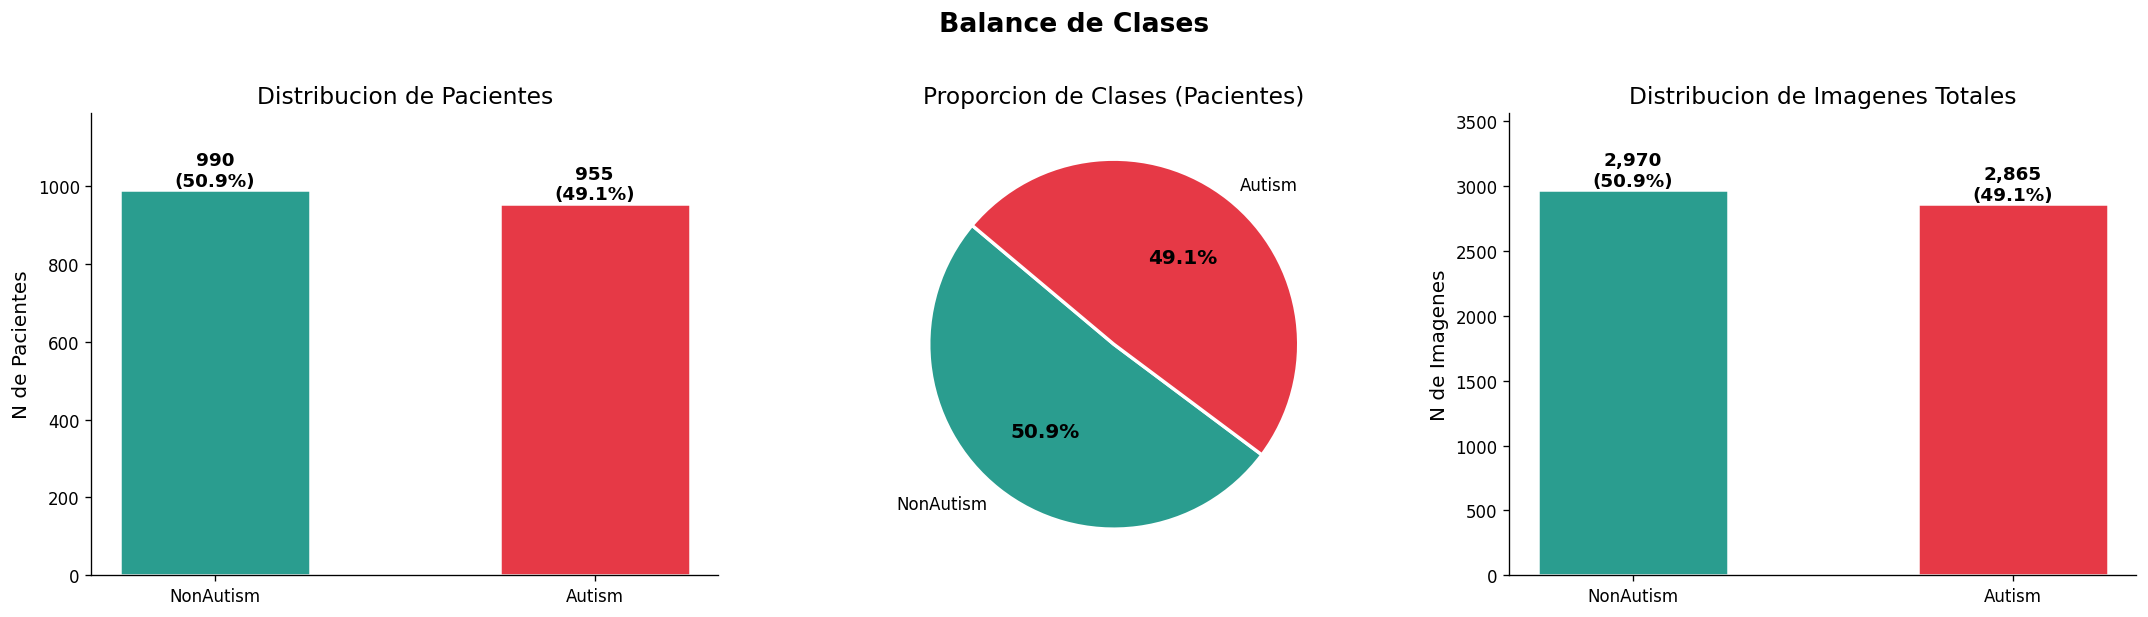


───────────────────────────────────────────────────────
  NIVEL PACIENTE
  Clase                   Count         %
───────────────────────────────────────────────────────
  NonAutism                 990     50.9%
  Autism                    955     49.1%
───────────────────────────────────────────────────────
  TOTAL                   1,945   100.0%
  Ratio de desbalance        1.04x
───────────────────────────────────────────────────────


In [6]:
# Balance a nivel de PACIENTE
df_patients     = df.drop_duplicates(subset=[PATIENT_ID_COL])[[PATIENT_ID_COL, LABEL_COL]]
counts_patients = df_patients[LABEL_COL].value_counts()
pct_patients    = (counts_patients / counts_patients.sum() * 100).round(2)
imbalance       = (counts_patients.max() / counts_patients.min()).round(2)

# Balance a nivel de IMAGEN
counts_images = df[LABEL_COL].value_counts()
pct_images    = (counts_images / counts_images.sum() * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Balance de Clases', fontsize=16, fontweight='bold', y=1.02)

colors_p = [CLASS_COLORS.get(c, '#888888') for c in counts_patients.index]

bars = axes[0].bar(counts_patients.index, counts_patients.values,
                   color=colors_p, width=0.5, edgecolor='white', linewidth=1.5)
for bar, v, p in zip(bars, counts_patients.values, pct_patients.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:,}\n({p}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribucion de Pacientes')
axes[0].set_ylabel('N de Pacientes')
axes[0].set_ylim(0, counts_patients.max() * 1.2)

wedges, texts, autotexts = axes[1].pie(
    counts_patients.values, labels=counts_patients.index, colors=colors_p,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporcion de Clases (Pacientes)')

colors_i = [CLASS_COLORS.get(c, '#888888') for c in counts_images.index]
bars2 = axes[2].bar(counts_images.index, counts_images.values,
                    color=colors_i, width=0.5, edgecolor='white', linewidth=1.5)
for bar, v, p in zip(bars2, counts_images.values, pct_images.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:,}\n({p}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].set_title('Distribucion de Imagenes Totales')
axes[2].set_ylabel('N de Imagenes')
axes[2].set_ylim(0, counts_images.max() * 1.2)

plt.tight_layout()
plt.show()

print(f"\n{'─'*55}")
print(f"  NIVEL PACIENTE")
print(f"  {'Clase':<20} {'Count':>8}    {'%':>6}")
print(f"{'─'*55}")
for cn, c, p in zip(counts_patients.index, counts_patients.values, pct_patients.values):
    print(f"  {cn:<20} {c:>8,}    {p:>5.1f}%")
print(f"{'─'*55}")
print(f"  {'TOTAL':<20} {counts_patients.sum():>8,}   100.0%")
print(f"  Ratio de desbalance    {imbalance:>8.2f}x")
print(f"{'─'*55}")

---
## 5. Distribucion de Cortes por Clase

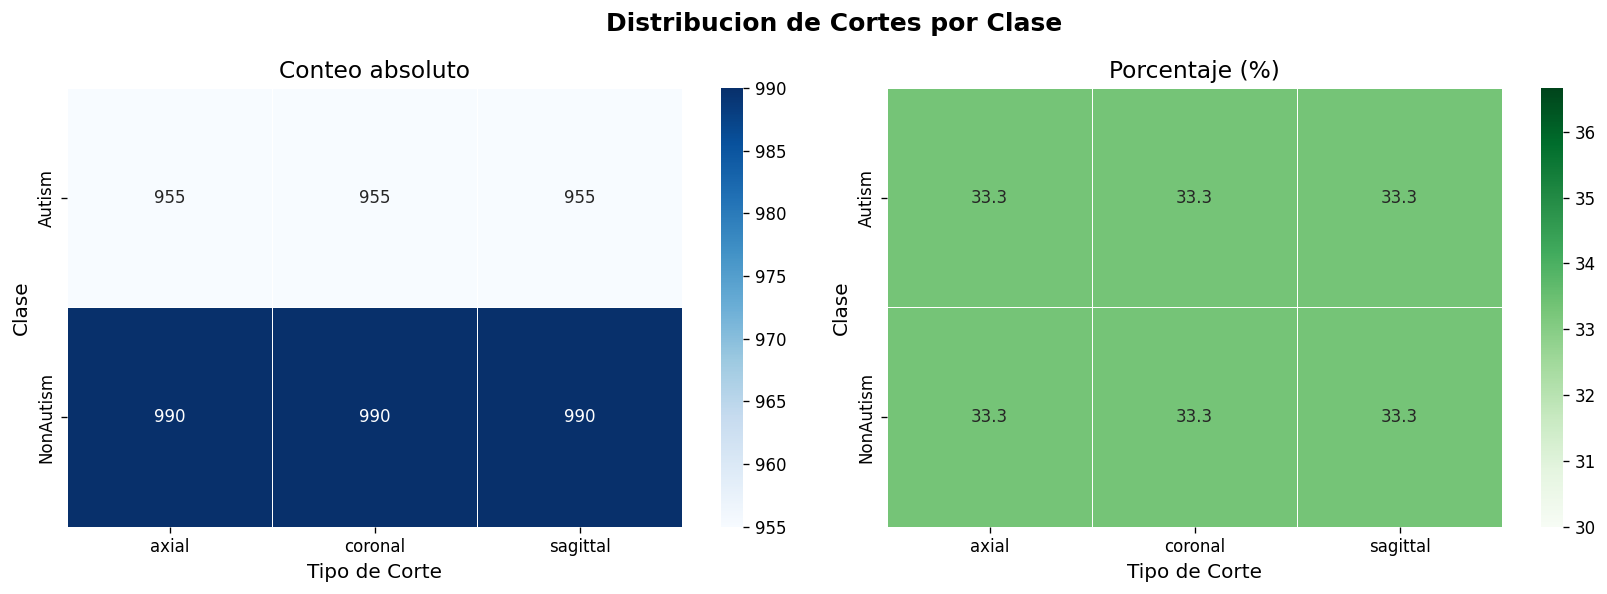


Tabla cruzada (conteos):
image_type  axial  coronal  sagittal
label                               
Autism        955      955       955
NonAutism     990      990       990

Tabla cruzada (porcentajes):
image_type  axial  coronal  sagittal
label                               
Autism      33.33    33.33     33.33
NonAutism   33.33    33.33     33.33


In [7]:
crosstab     = pd.crosstab(df[LABEL_COL], df[SLICE_TYPE_COL])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de Cortes por Clase', fontsize=15, fontweight='bold')

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0])
axes[0].set_title('Conteo absoluto')
axes[0].set_xlabel('Tipo de Corte')
axes[0].set_ylabel('Clase')

sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Greens', linewidths=0.5, ax=axes[1])
axes[1].set_title('Porcentaje (%)')
axes[1].set_xlabel('Tipo de Corte')
axes[1].set_ylabel('Clase')

plt.tight_layout()
plt.show()

print('\nTabla cruzada (conteos):')
print(crosstab)
print('\nTabla cruzada (porcentajes):')
print(crosstab_pct.round(2))

---
## 6. Extraccion de Metadatos de Imagen

In [8]:
def decode_image(img_bytes):
    """Convierte bytes PNG a imagen PIL en RGB."""
    return Image.open(io.BytesIO(img_bytes)).convert('RGB')


def extract_metadata(img_bytes):
    """Extrae metadatos estadisticos de imagen a partir de sus bytes."""
    try:
        img_pil = decode_image(img_bytes)
        w, h    = img_pil.size
        img_np  = np.array(img_pil)
        gray    = np.array(img_pil.convert('L'))

        return {
            'width'        : w,
            'height'       : h,
            'aspect_ratio' : round(w / h, 3),
            'num_channels' : img_np.shape[2] if img_np.ndim == 3 else 1,
            'mean_r'       : float(img_np[:, :, 0].mean()),
            'mean_g'       : float(img_np[:, :, 1].mean()),
            'mean_b'       : float(img_np[:, :, 2].mean()),
            'std_r'        : float(img_np[:, :, 0].std()),
            'std_g'        : float(img_np[:, :, 1].std()),
            'std_b'        : float(img_np[:, :, 2].std()),
            'global_mean'  : float(img_np.mean()),
            'global_std'   : float(img_np.std()),
            'brightness'   : float(gray.mean()),
            'contrast'     : float(gray.std()),
            'is_corrupt'   : False,
        }
    except Exception:
        meta = {k: np.nan for k in [
            'width', 'height', 'aspect_ratio', 'num_channels',
            'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b',
            'global_mean', 'global_std', 'brightness', 'contrast',
        ]}
        meta['is_corrupt'] = True
        return meta


print('Extrayendo metadatos de imagenes...')
print('Este proceso puede tardar varios minutos.')

meta_list = [extract_metadata(b) for b in df['image_bytes']]
df_meta   = pd.DataFrame(meta_list)
df        = pd.concat([df.reset_index(drop=True), df_meta], axis=1)

corrupted = int(df['is_corrupt'].sum())
print(f'Extraccion completa.')
print(f'   Total imagenes procesadas : {len(df):,}')
print(f'   Imagenes corruptas        : {corrupted}')

df.describe().T

Extrayendo metadatos de imagenes...
Este proceso puede tardar varios minutos.
Extraccion completa.
   Total imagenes procesadas : 5,835
   Imagenes corruptas        : 0


,count,mean,std,min,25%,50%,75%,max
width,5835.0,257.847644,76.058844,80.000000,224.000000,224.000000,301.000000,465.000000
height,5835.0,255.853299,39.075787,145.000000,224.000000,224.000000,302.000000,302.000000
aspect_ratio,5835.0,1.016767,0.289474,0.265000,0.997000,1.000000,1.000000,3.207000
num_channels,5835.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean_r,5835.0,31.653068,12.755193,7.474769,22.057757,30.055399,38.732891,93.579263
mean_g,5835.0,31.653068,12.755193,7.474769,22.057757,30.055399,38.732891,93.579263
mean_b,5835.0,31.653068,12.755193,7.474769,22.057757,30.055399,38.732891,93.579263
std_r,5835.0,39.369855,12.023578,9.922391,29.991310,38.458758,46.797765,79.288518
std_g,5835.0,39.369855,12.023578,9.922391,29.991310,38.458758,46.797765,79.288518
std_b,5835.0,39.369855,12.023578,9.922391,29.991310,38.458758,46.797765,79.288518


---
## 7. Analisis de Resolucion y Dimensiones

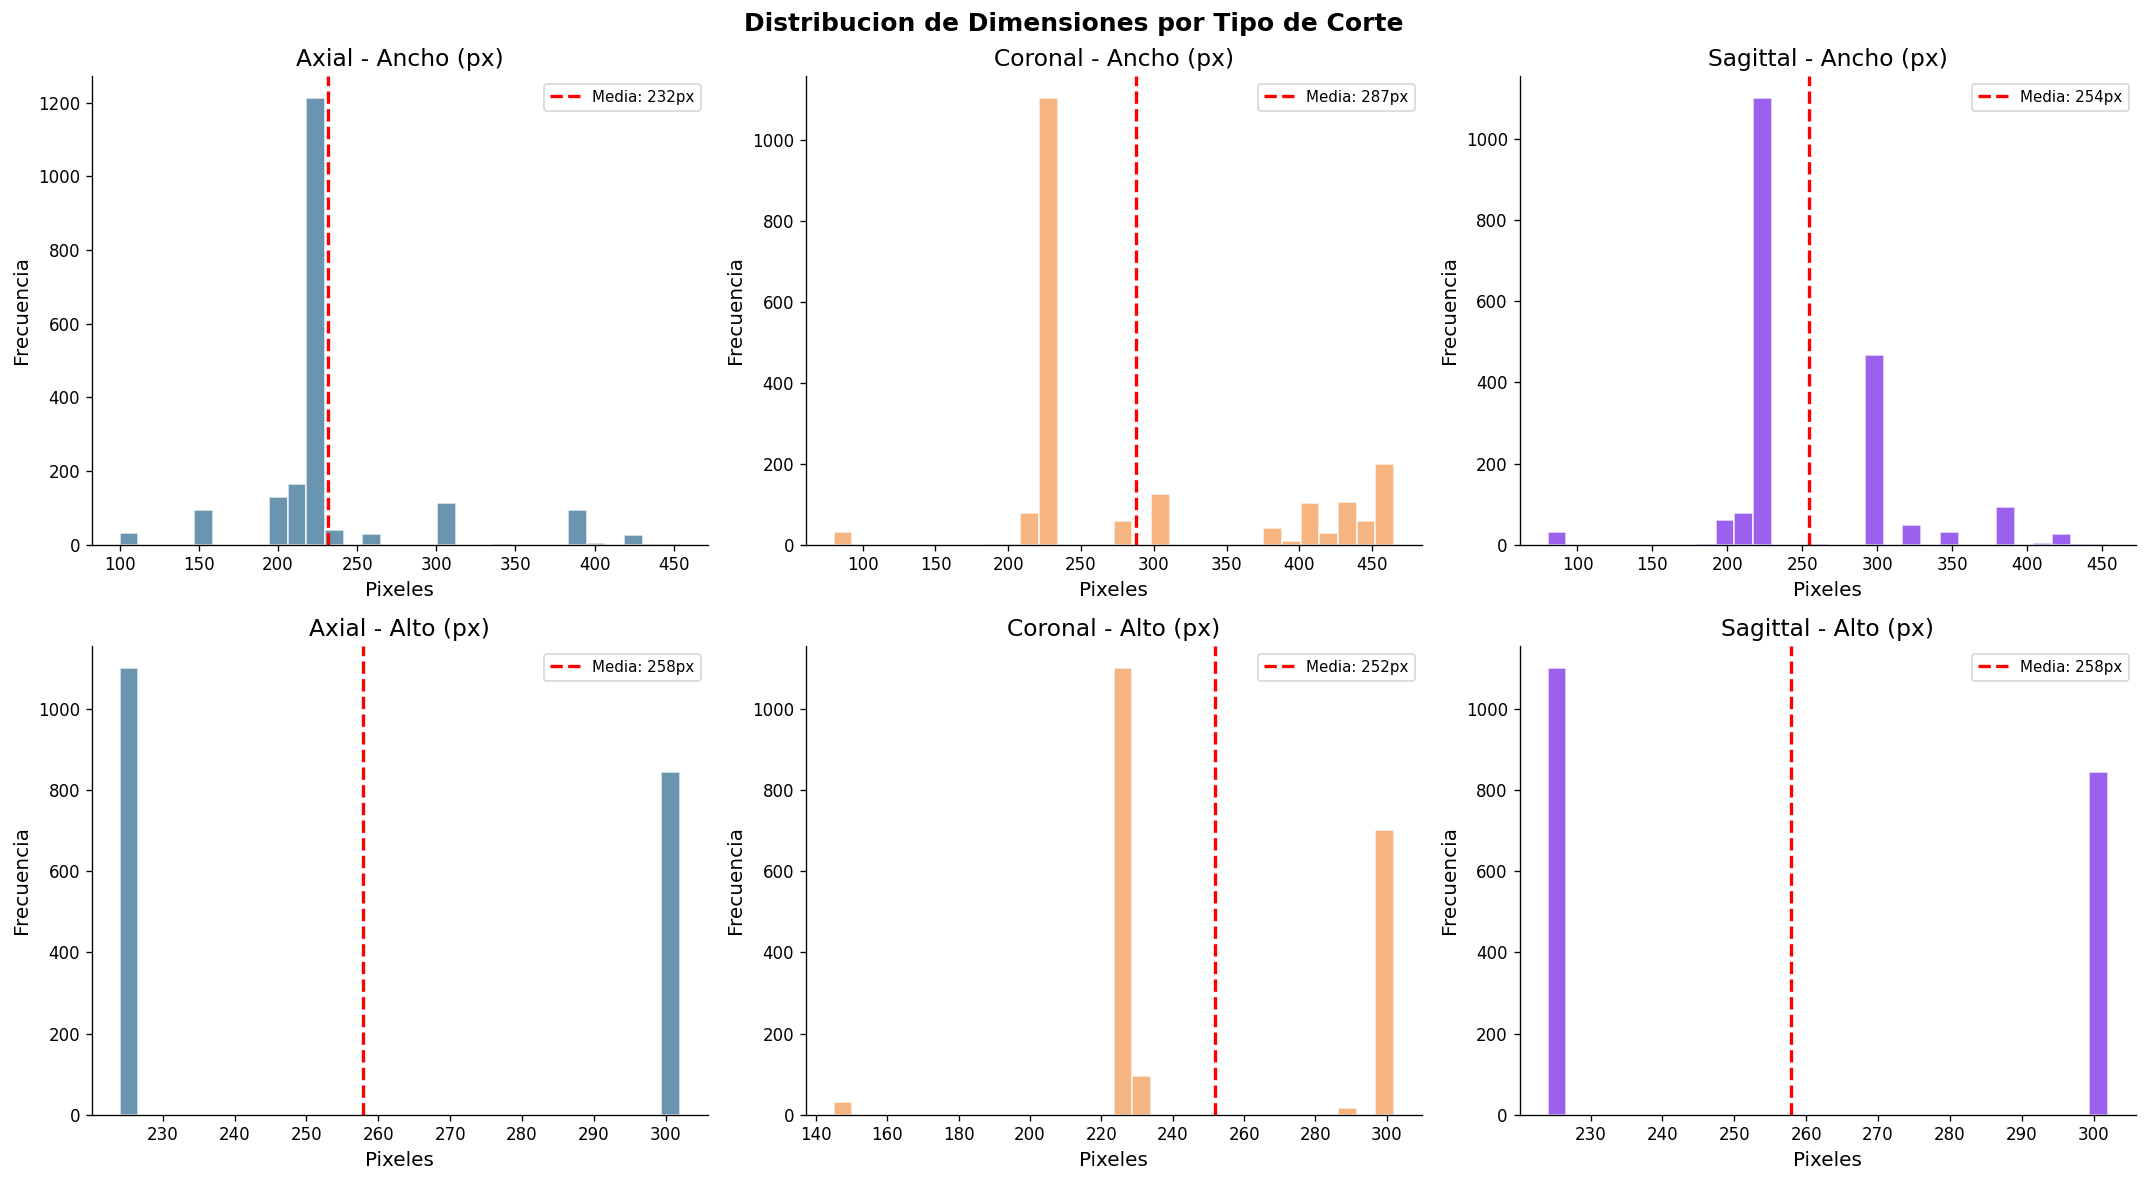


Estadisticas de Resolucion por Tipo de Corte:
────────────────────────────────────────────────────────────────────────────────
  Corte         W-Media   W-Std   W-Min   W-Max |  H-Media   H-Std   H-Min   H-Max
────────────────────────────────────────────────────────────────────────────────
  axial           231.9    53.3     100     454 |    257.9    38.7     224     302
  coronal         287.4    98.3      80     465 |    251.8    39.6     145     302
  sagittal        254.2    57.4      80     454 |    257.9    38.7     224     302
────────────────────────────────────────────────────────────────────────────────


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribucion de Dimensiones por Tipo de Corte',
             fontsize=15, fontweight='bold')

slice_colors = [PALETTE['axial'], PALETTE['coronal'], PALETTE['sagittal']]

for i, (st, color) in enumerate(zip(SLICE_TYPES, slice_colors)):
    d = df[df[SLICE_TYPE_COL] == st]

    axes[0, i].hist(d['width'].dropna(), bins=30, color=color, alpha=0.8, edgecolor='white')
    axes[0, i].axvline(d['width'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Media: {d["width"].mean():.0f}px')
    axes[0, i].set_title(f'{st.capitalize()} - Ancho (px)')
    axes[0, i].set_xlabel('Pixeles')
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].legend(fontsize=9)

    axes[1, i].hist(d['height'].dropna(), bins=30, color=color, alpha=0.8, edgecolor='white')
    axes[1, i].axvline(d['height'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Media: {d["height"].mean():.0f}px')
    axes[1, i].set_title(f'{st.capitalize()} - Alto (px)')
    axes[1, i].set_xlabel('Pixeles')
    axes[1, i].set_ylabel('Frecuencia')
    axes[1, i].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nEstadisticas de Resolucion por Tipo de Corte:')
print(f"{'─'*80}")
print(f"  {'Corte':<12} {'W-Media':>8} {'W-Std':>7} {'W-Min':>7} {'W-Max':>7} | "
      f"{'H-Media':>8} {'H-Std':>7} {'H-Min':>7} {'H-Max':>7}")
print(f"{'─'*80}")
for st in SLICE_TYPES:
    d = df[df[SLICE_TYPE_COL] == st]
    print(f"  {st:<12} {d['width'].mean():>8.1f} {d['width'].std():>7.1f} "
          f"{d['width'].min():>7.0f} {d['width'].max():>7.0f} | "
          f"{d['height'].mean():>8.1f} {d['height'].std():>7.1f} "
          f"{d['height'].min():>7.0f} {d['height'].max():>7.0f}")
print(f"{'─'*80}")

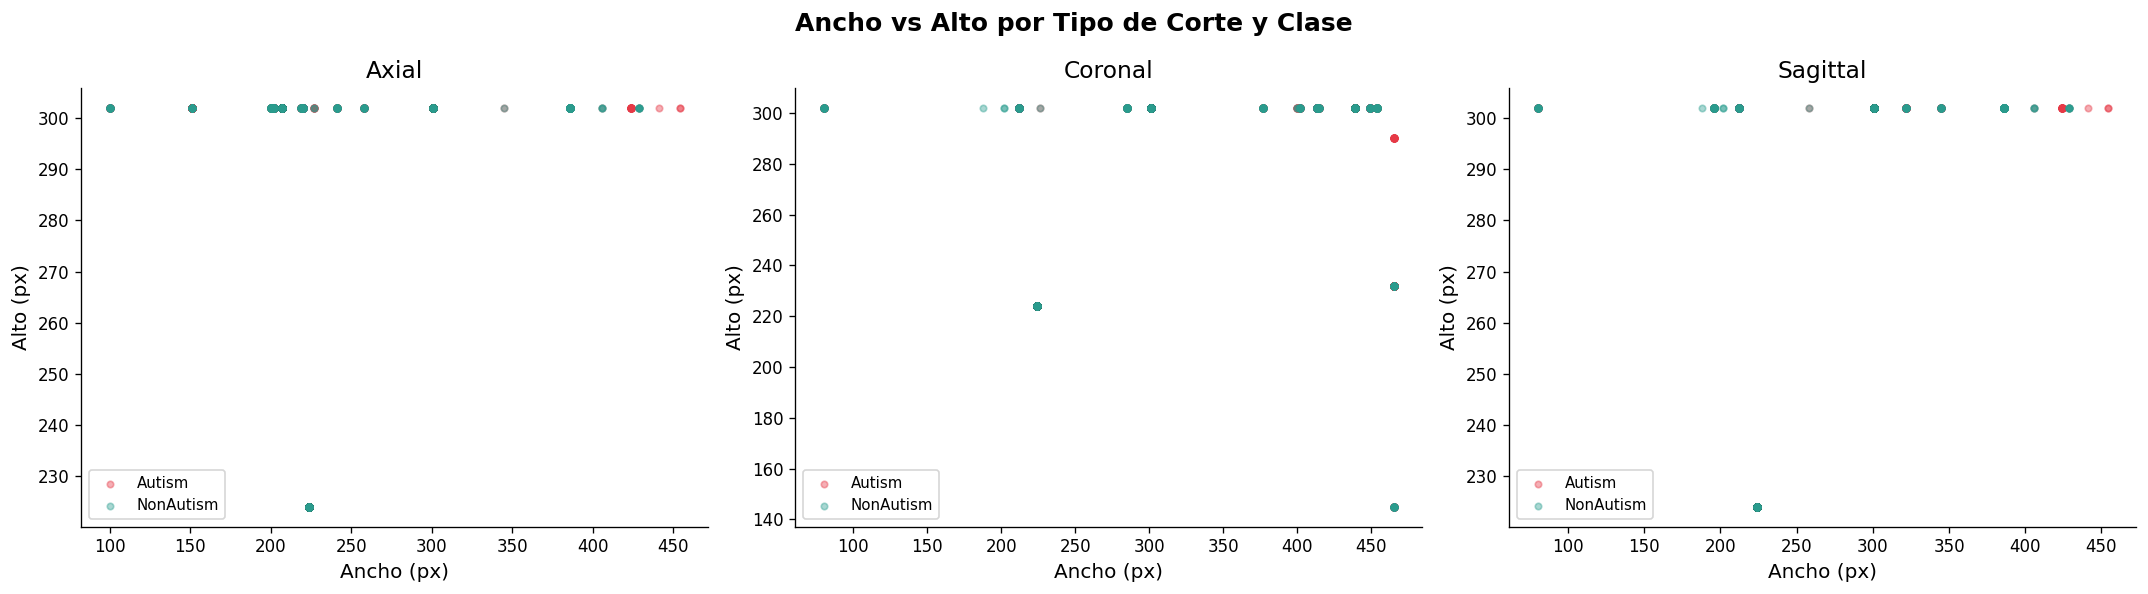

Resolucion dominante : 224x224 px
Imagenes con resolucion diferente: 2,535


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ancho vs Alto por Tipo de Corte y Clase', fontsize=15, fontweight='bold')

for i, st in enumerate(SLICE_TYPES):
    ax = axes[i]
    d  = df[df[SLICE_TYPE_COL] == st]
    for cls_name, color in CLASS_COLORS.items():
        ds = d[d[LABEL_COL] == cls_name]
        ax.scatter(ds['width'], ds['height'], alpha=0.4, s=15, color=color, label=cls_name)
    ax.set_title(f'{st.capitalize()}')
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

most_common_w = int(df['width'].mode()[0])
most_common_h = int(df['height'].mode()[0])
diff_res = df[(df['width'] != most_common_w) | (df['height'] != most_common_h)]
print(f'Resolucion dominante : {most_common_w}x{most_common_h} px')
print(f'Imagenes con resolucion diferente: {len(diff_res):,}')

---
## 8. Analisis de Brillo y Contraste

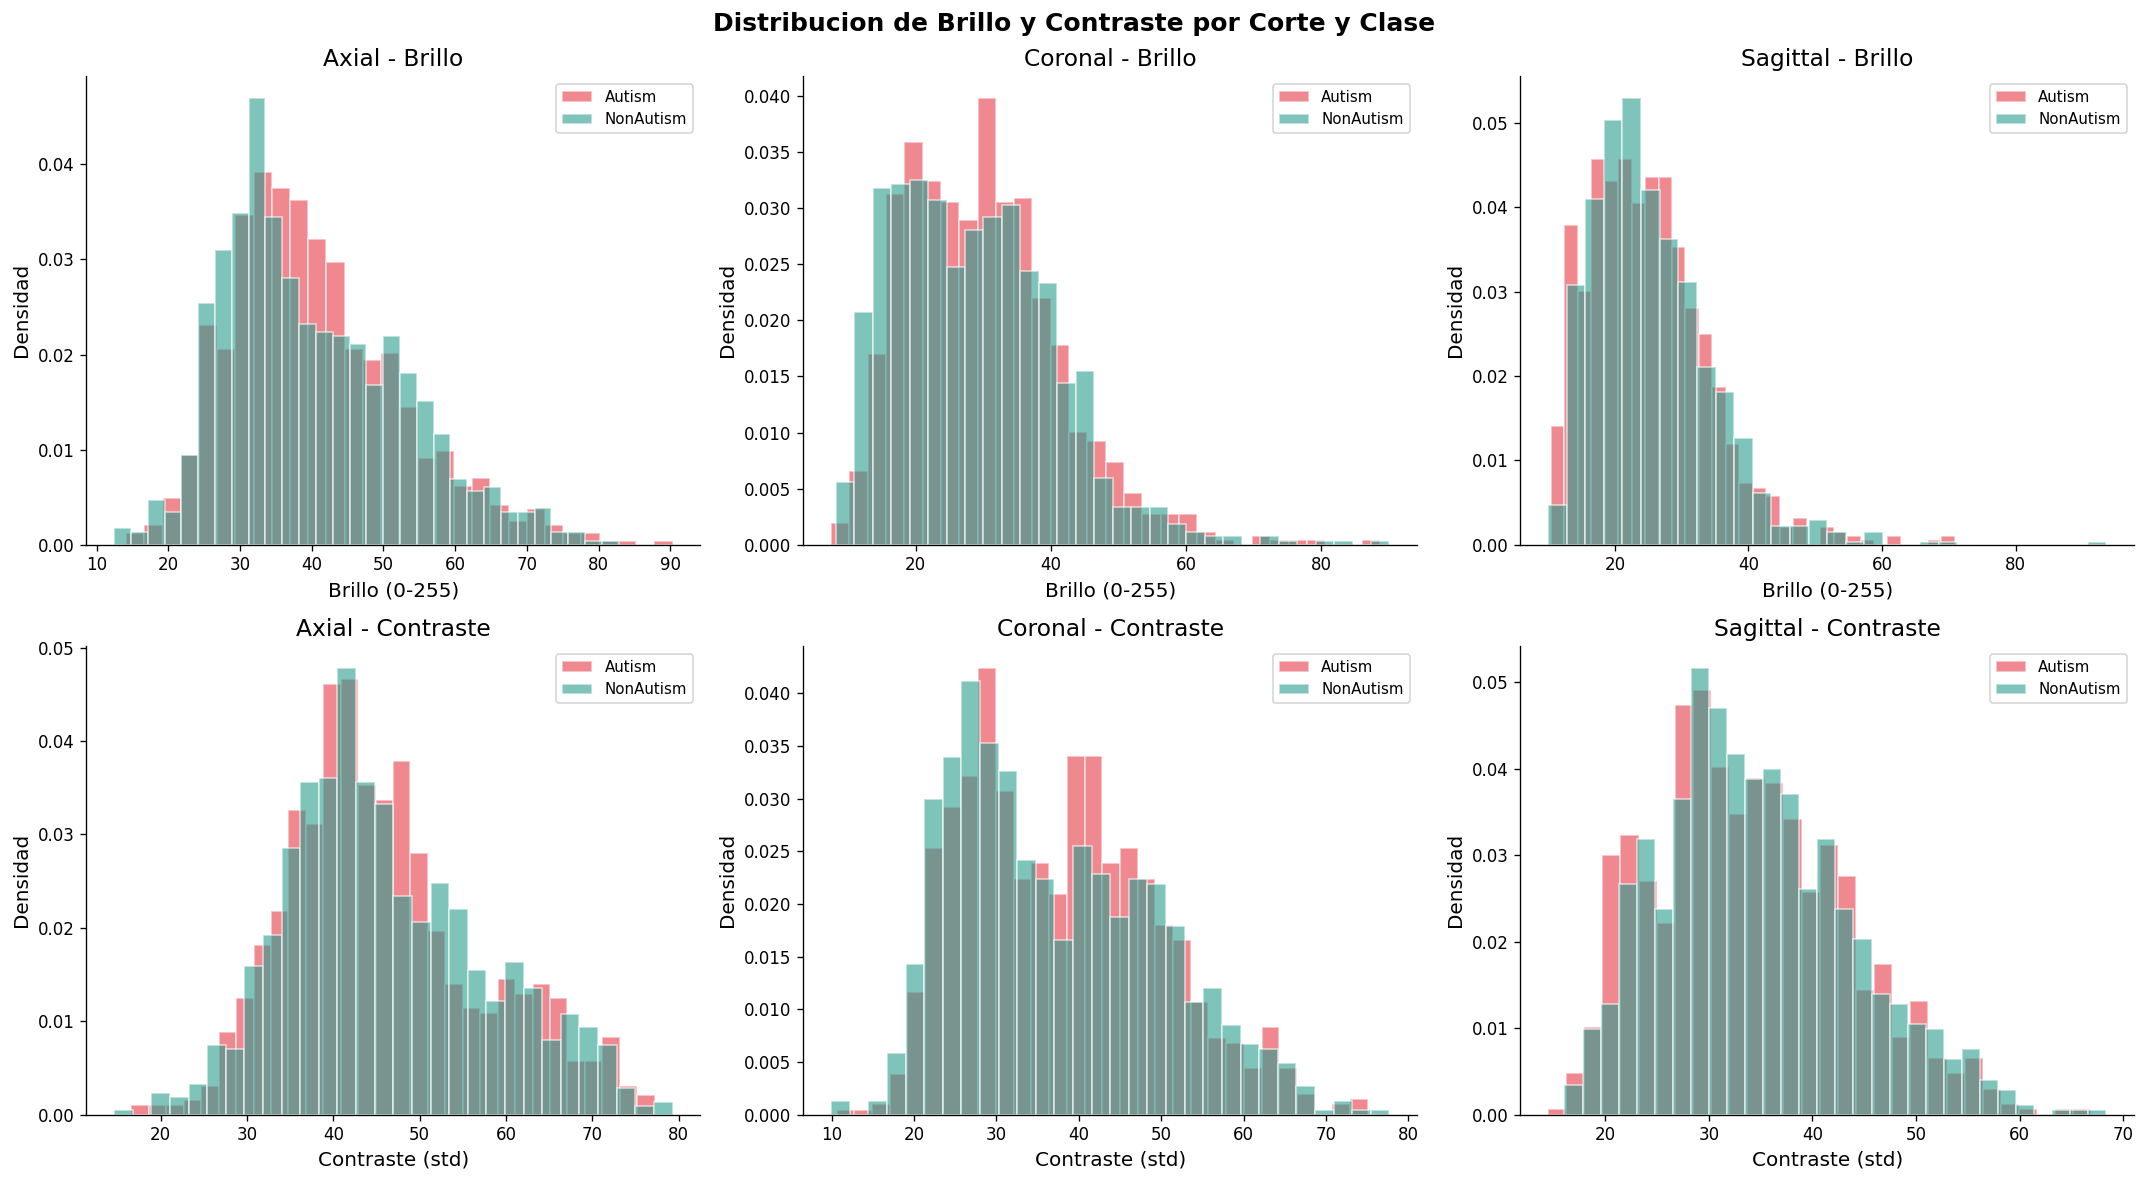

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribucion de Brillo y Contraste por Corte y Clase',
             fontsize=15, fontweight='bold')

for i, st in enumerate(SLICE_TYPES):
    ds = df[df[SLICE_TYPE_COL] == st]
    for cls_name, color in CLASS_COLORS.items():
        d = ds[ds[LABEL_COL] == cls_name]
        axes[0, i].hist(d['brightness'].dropna(), bins=30, alpha=0.6,
                        color=color, label=cls_name, edgecolor='white', density=True)
        axes[1, i].hist(d['contrast'].dropna(), bins=30, alpha=0.6,
                        color=color, label=cls_name, edgecolor='white', density=True)

    axes[0, i].set_title(f'{st.capitalize()} - Brillo')
    axes[0, i].set_xlabel('Brillo (0-255)')
    axes[0, i].set_ylabel('Densidad')
    axes[0, i].legend(fontsize=9)

    axes[1, i].set_title(f'{st.capitalize()} - Contraste')
    axes[1, i].set_xlabel('Contraste (std)')
    axes[1, i].set_ylabel('Densidad')
    axes[1, i].legend(fontsize=9)

plt.tight_layout()
plt.show()

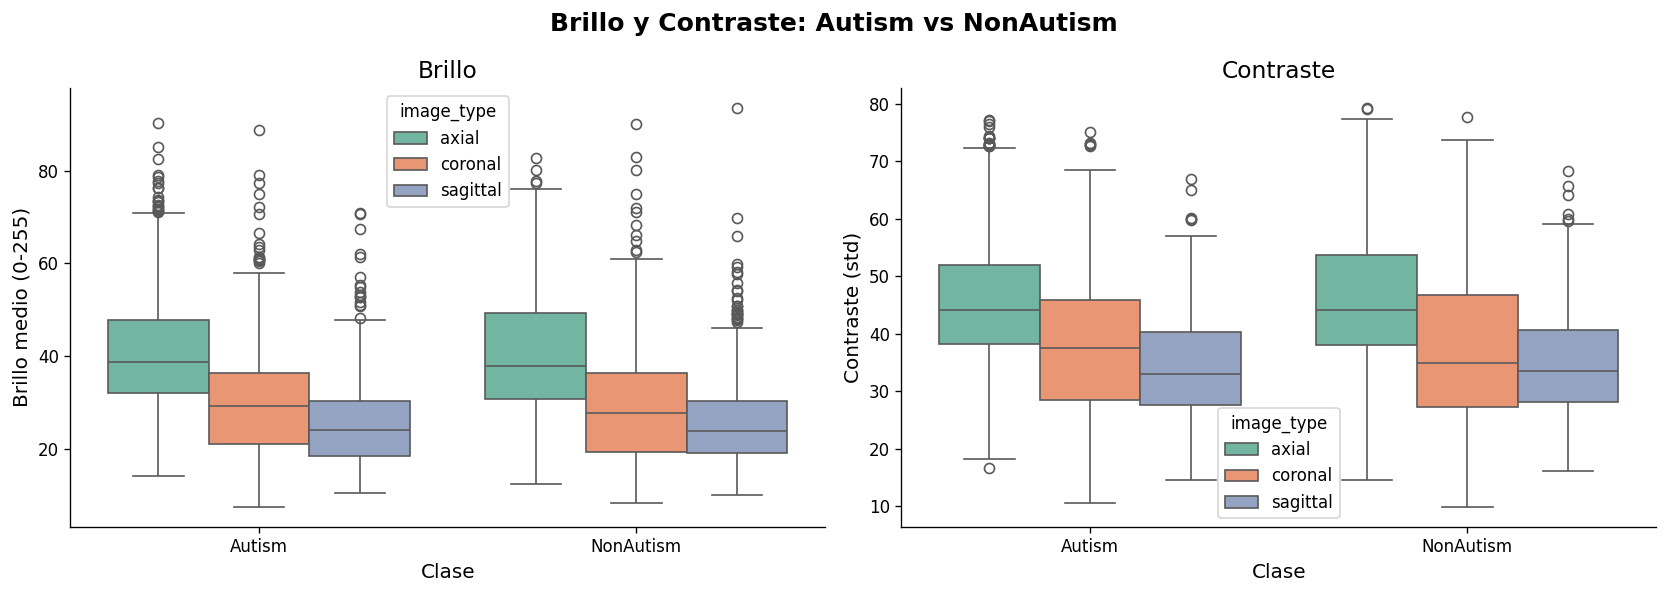

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brillo y Contraste: Autism vs NonAutism', fontsize=15, fontweight='bold')

sns.boxplot(data=df, x=LABEL_COL, y='brightness', hue=SLICE_TYPE_COL,
            ax=axes[0], palette='Set2', order=CLASS_NAMES)
axes[0].set_title('Brillo')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Brillo medio (0-255)')

sns.boxplot(data=df, x=LABEL_COL, y='contrast', hue=SLICE_TYPE_COL,
            ax=axes[1], palette='Set2', order=CLASS_NAMES)
axes[1].set_title('Contraste')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Contraste (std)')

plt.tight_layout()
plt.show()

---
## 9. Analisis de Canales RGB

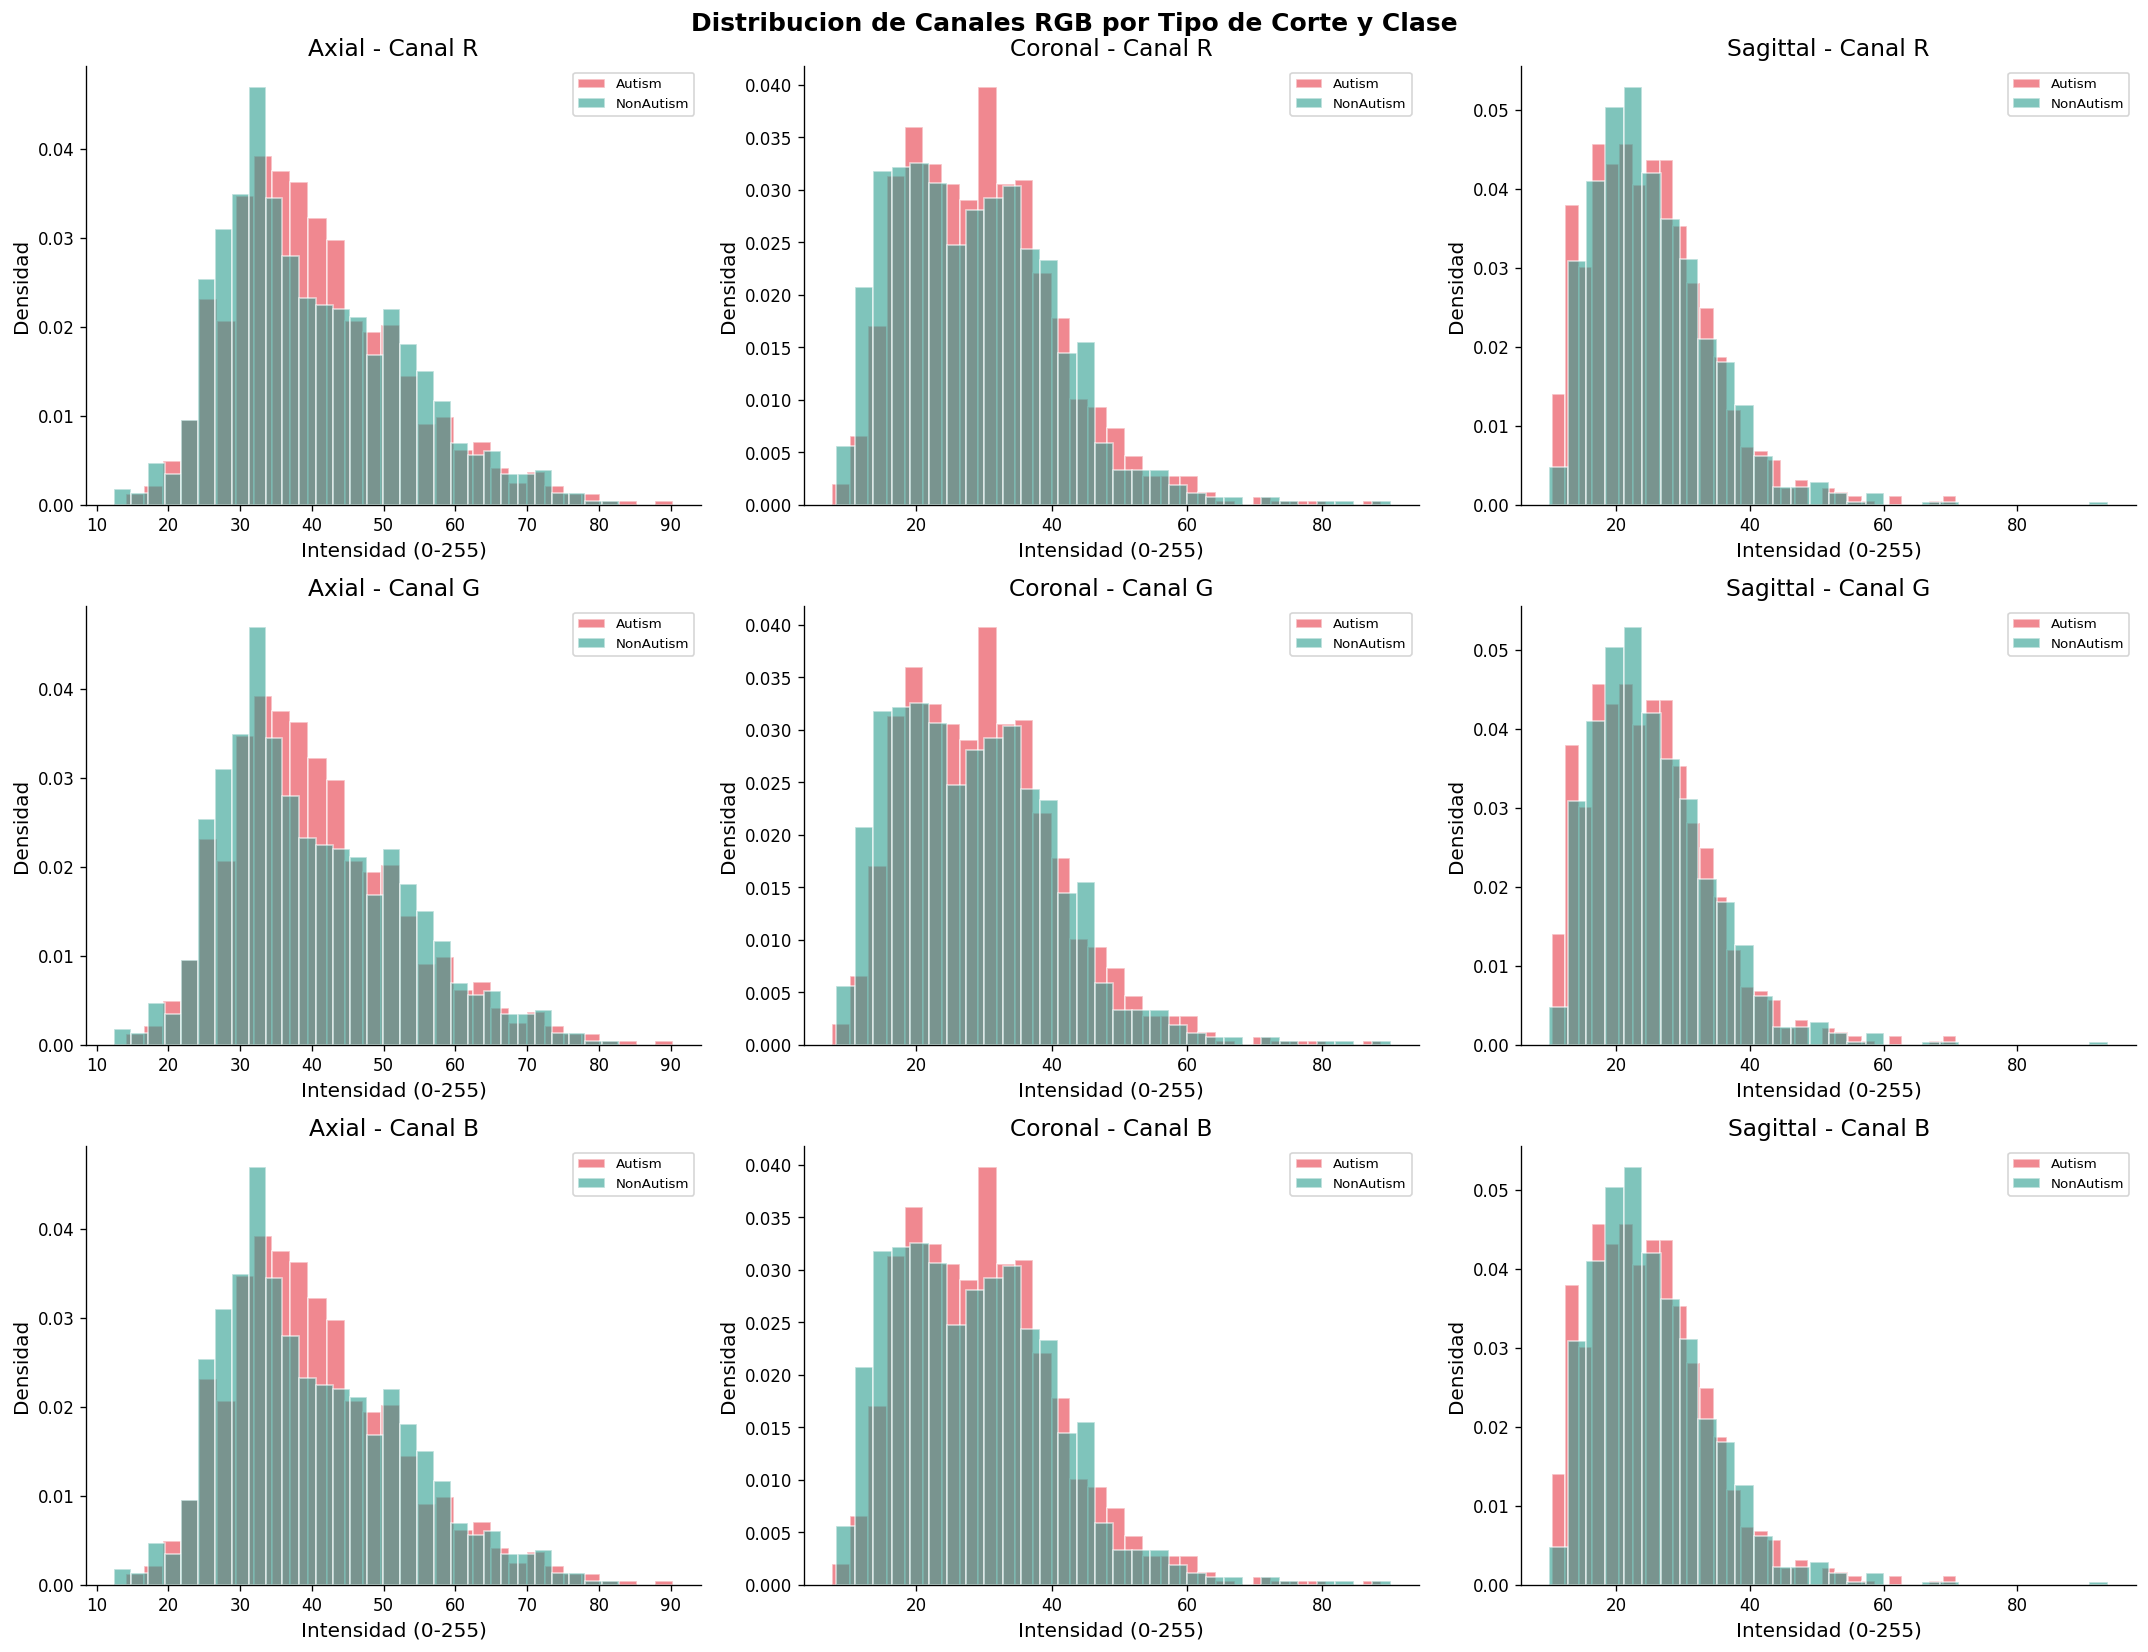

In [13]:
rgb_metrics = ['mean_r', 'mean_g', 'mean_b']
rgb_labels  = ['Canal R', 'Canal G', 'Canal B']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribucion de Canales RGB por Tipo de Corte y Clase',
             fontsize=15, fontweight='bold')

for row_i, (metric, label) in enumerate(zip(rgb_metrics, rgb_labels)):
    for col_i, st in enumerate(SLICE_TYPES):
        ax = axes[row_i, col_i]
        ds = df[df[SLICE_TYPE_COL] == st]
        for cls_name, color in CLASS_COLORS.items():
            d = ds[ds[LABEL_COL] == cls_name][metric].dropna()
            ax.hist(d, bins=30, alpha=0.6, color=color, label=cls_name,
                    edgecolor='white', density=True)
        ax.set_title(f'{st.capitalize()} - {label}')
        ax.set_xlabel('Intensidad (0-255)')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. Tests Estadisticos (Mann-Whitney U)

In [14]:
numeric_features = [
    'brightness', 'contrast', 'global_mean', 'global_std',
    'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b',
]

class_a = df[df[LABEL_COL] == 'Autism']
class_c = df[df[LABEL_COL] == 'NonAutism']

results = []
for feat in numeric_features:
    a_vals = class_a[feat].dropna()
    c_vals = class_c[feat].dropna()
    if len(a_vals) > 0 and len(c_vals) > 0:
        stat, p_val = mannwhitneyu(a_vals, c_vals, alternative='two-sided')
        results.append({
            'feature'         : feat,
            'autism_mean'     : round(float(a_vals.mean()), 3),
            'nonautism_mean'  : round(float(c_vals.mean()), 3),
            'diff'            : round(float(a_vals.mean() - c_vals.mean()), 3),
            'MW_stat'         : round(float(stat), 2),
            'p_value'         : round(float(p_val), 6),
            'significant'     : 'SI' if p_val < 0.05 else 'NO',
        })

df_results = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
print('Tests Mann-Whitney U - Autism vs NonAutism (todas las imagenes):')
print(df_results.to_string(index=False))

Tests Mann-Whitney U - Autism vs NonAutism (todas las imagenes):
    feature  autism_mean  nonautism_mean   diff   MW_stat  p_value significant
 brightness       31.829          31.483  0.346 4351156.0 0.133064          NO
global_mean       31.829          31.483  0.346 4351156.0 0.133064          NO
     mean_g       31.829          31.483  0.346 4351156.0 0.133064          NO
     mean_r       31.829          31.483  0.346 4351156.0 0.133064          NO
     mean_b       31.829          31.483  0.346 4351156.0 0.133064          NO
   contrast       39.326          39.412 -0.087 4259376.0 0.939895          NO
 global_std       39.326          39.412 -0.087 4259376.0 0.939895          NO
      std_r       39.326          39.412 -0.087 4259376.0 0.939895          NO
      std_g       39.326          39.412 -0.087 4259376.0 0.939895          NO
      std_b       39.326          39.412 -0.087 4259376.0 0.939895          NO


In [15]:
key_features = ['brightness', 'contrast', 'global_mean', 'global_std']

print('Tests Mann-Whitney U por tipo de corte:')
print('='*72)

for st in SLICE_TYPES:
    ds  = df[df[SLICE_TYPE_COL] == st]
    a_s = ds[ds[LABEL_COL] == 'Autism']
    c_s = ds[ds[LABEL_COL] == 'NonAutism']

    print(f'\nCorte: {st.upper()}')
    print(f"{'─'*72}")
    print(f"  {'Feature':<18} {'Autism':>10} {'NonAutism':>10} {'Diff':>10} {'p-value':>12} {'Sig':>5}")
    print(f"{'─'*72}")

    for feat in key_features:
        a_v = a_s[feat].dropna()
        c_v = c_s[feat].dropna()
        if len(a_v) > 0 and len(c_v) > 0:
            stat, p = mannwhitneyu(a_v, c_v, alternative='two-sided')
            sig = 'SI' if p < 0.05 else 'NO'
            print(f"  {feat:<18} {float(a_v.mean()):>10.3f} {float(c_v.mean()):>10.3f} "
                  f"{float(a_v.mean()-c_v.mean()):>10.3f} {float(p):>12.6f} {sig:>5}")

Tests Mann-Whitney U por tipo de corte:

Corte: AXIAL
────────────────────────────────────────────────────────────────────────
  Feature                Autism  NonAutism       Diff      p-value   Sig
────────────────────────────────────────────────────────────────────────
  brightness             40.654     40.228      0.426     0.231624    NO
  contrast               46.005     46.250     -0.244     0.638884    NO
  global_mean            40.654     40.228      0.426     0.231624    NO
  global_std             46.005     46.250     -0.244     0.638884    NO

Corte: CORONAL
────────────────────────────────────────────────────────────────────────
  Feature                Autism  NonAutism       Diff      p-value   Sig
────────────────────────────────────────────────────────────────────────
  brightness             29.833     28.744      1.089     0.018815    SI
  contrast               37.999     37.289      0.710     0.083584    NO
  global_mean            29.833     28.744      1.089 

---
## 11. Visualizacion de Imagenes de Muestra

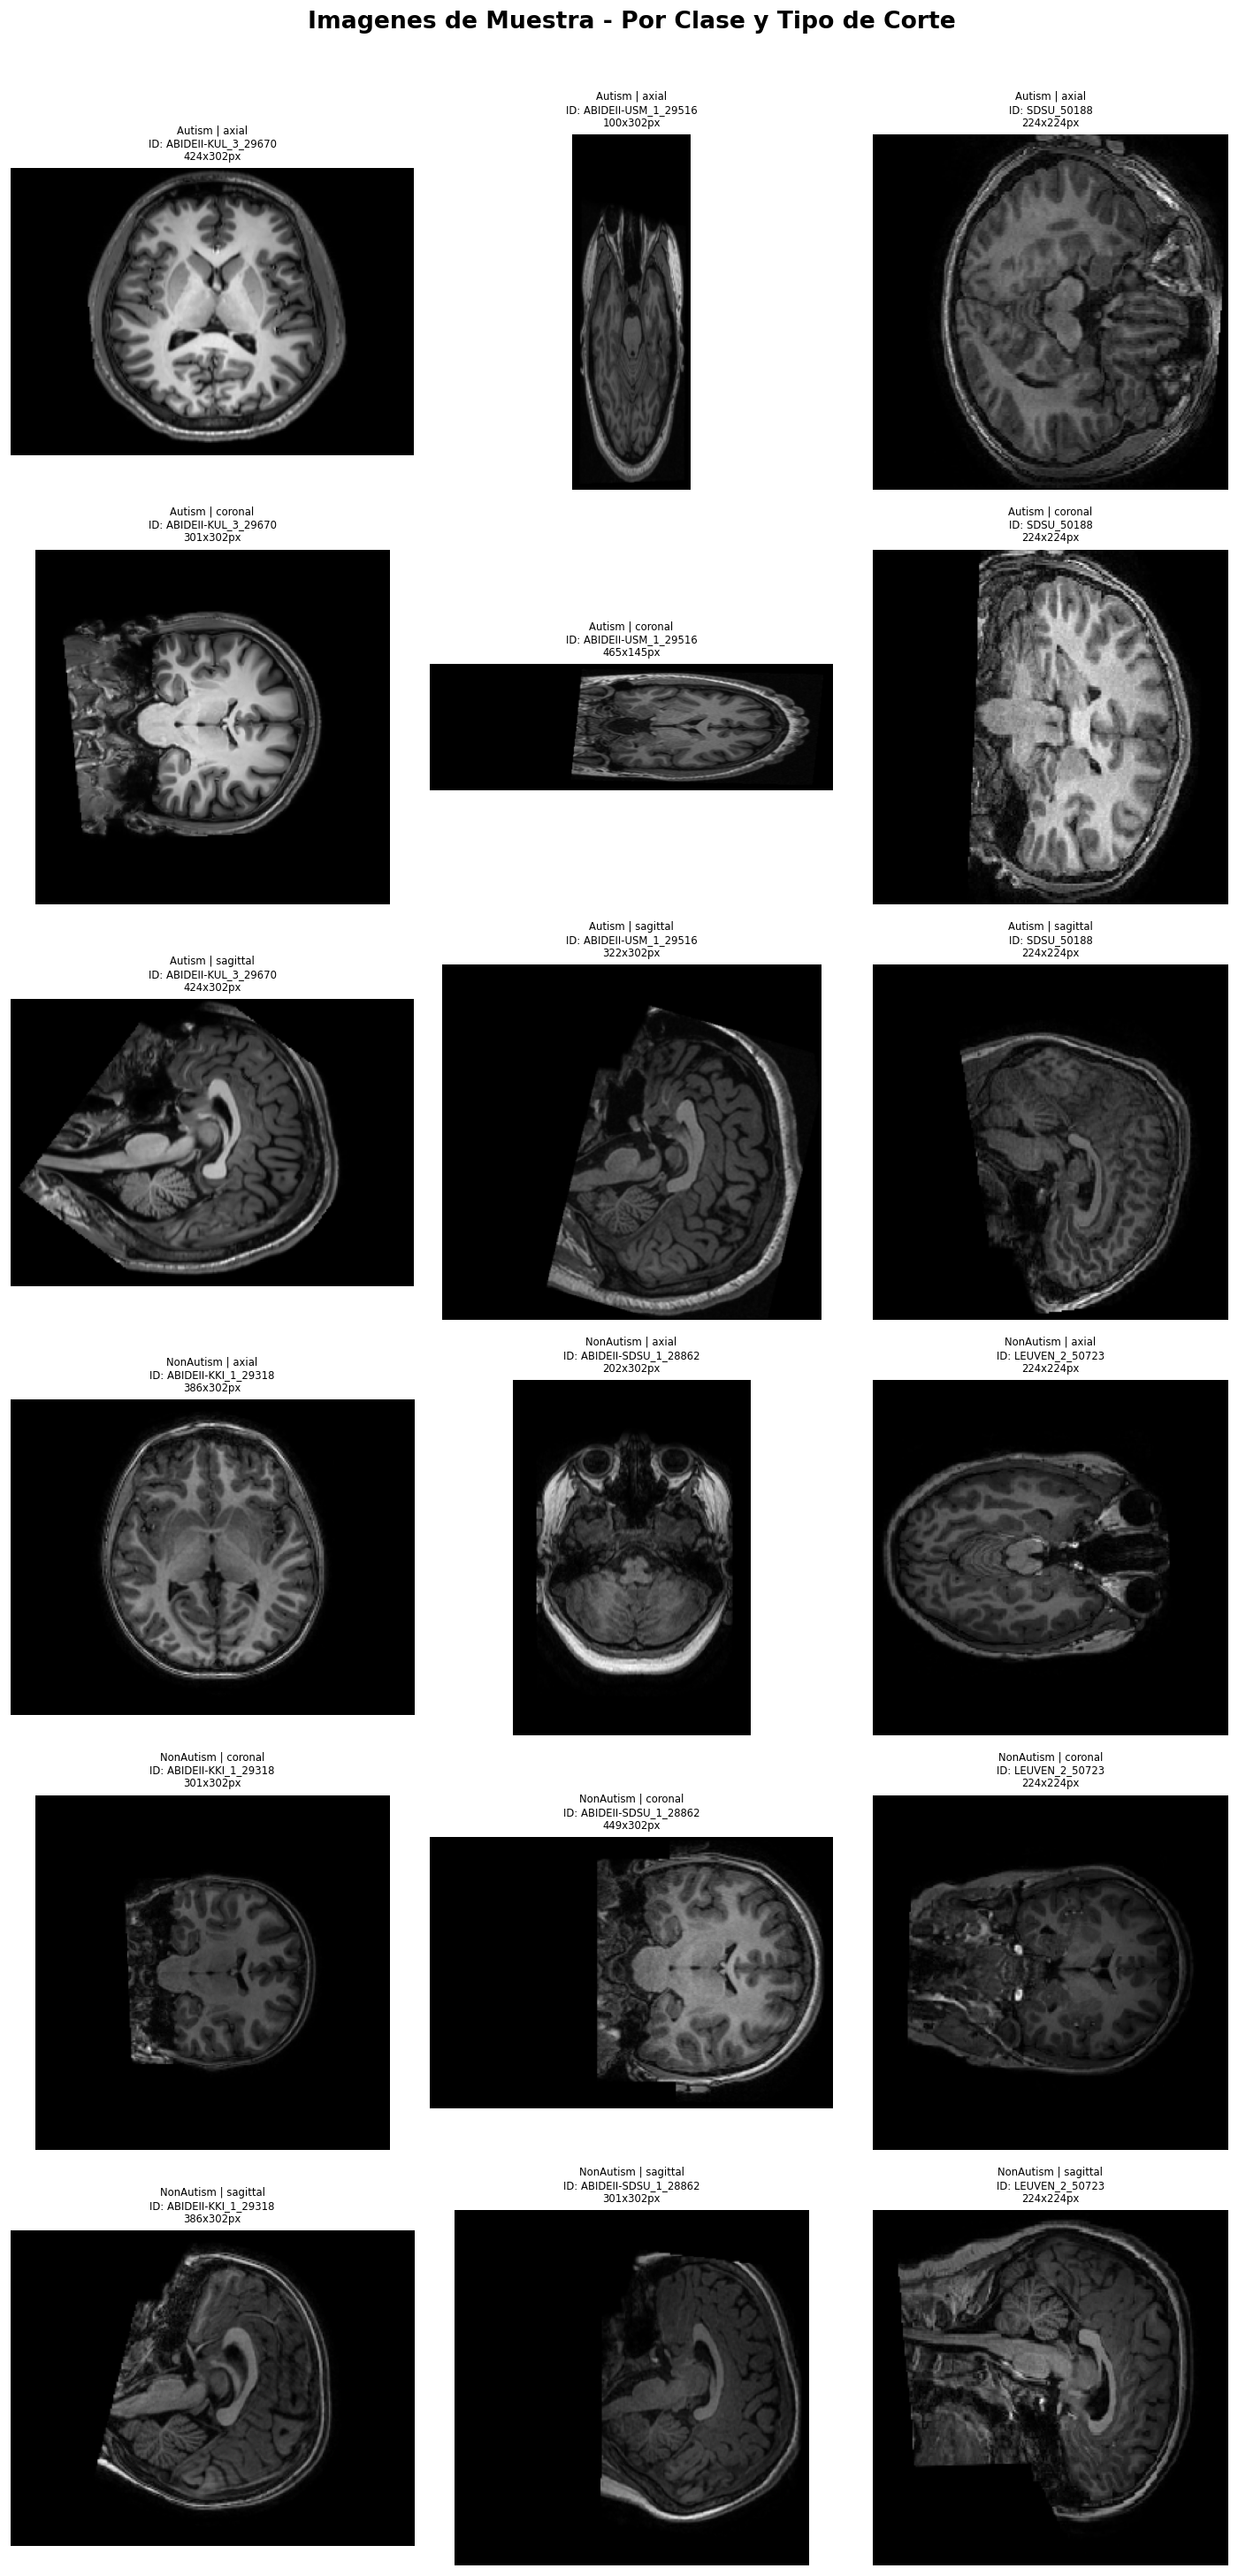

In [16]:
n_samples = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES) * len(SLICE_TYPES), n_samples,
    figsize=(n_samples * 4, len(CLASS_NAMES) * len(SLICE_TYPES) * 4)
)
fig.suptitle('Imagenes de Muestra - Por Clase y Tipo de Corte',
             fontsize=16, fontweight='bold', y=1.01)

row = 0
for cls_name in CLASS_NAMES:
    for st in SLICE_TYPES:
        df_sub  = df[(df[SLICE_TYPE_COL] == st) & (df[LABEL_COL] == cls_name)]
        samples = df_sub.sample(min(n_samples, len(df_sub)), random_state=42)

        for col_i, (_, rowdata) in enumerate(samples.iterrows()):
            try:
                img = decode_image(rowdata['image_bytes'])
                axes[row, col_i].imshow(img)
                axes[row, col_i].set_title(
                    f'{cls_name} | {st}\n'
                    f'ID: {rowdata[PATIENT_ID_COL]}\n'
                    f'{int(rowdata["width"])}x{int(rowdata["height"])}px',
                    fontsize=7
                )
                border_color = CLASS_COLORS.get(cls_name, 'gray')
                for spine in axes[row, col_i].spines.values():
                    spine.set_edgecolor(border_color)
                    spine.set_linewidth(3)
                    spine.set_visible(True)
            except Exception as e:
                axes[row, col_i].text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center')
            axes[row, col_i].axis('off')

        for col_i in range(len(samples), n_samples):
            axes[row, col_i].axis('off')

        row += 1

plt.tight_layout()
plt.show()

---
## 12. Tres Cortes del Mismo Paciente

Pacientes con los 3 cortes completos: 1,945


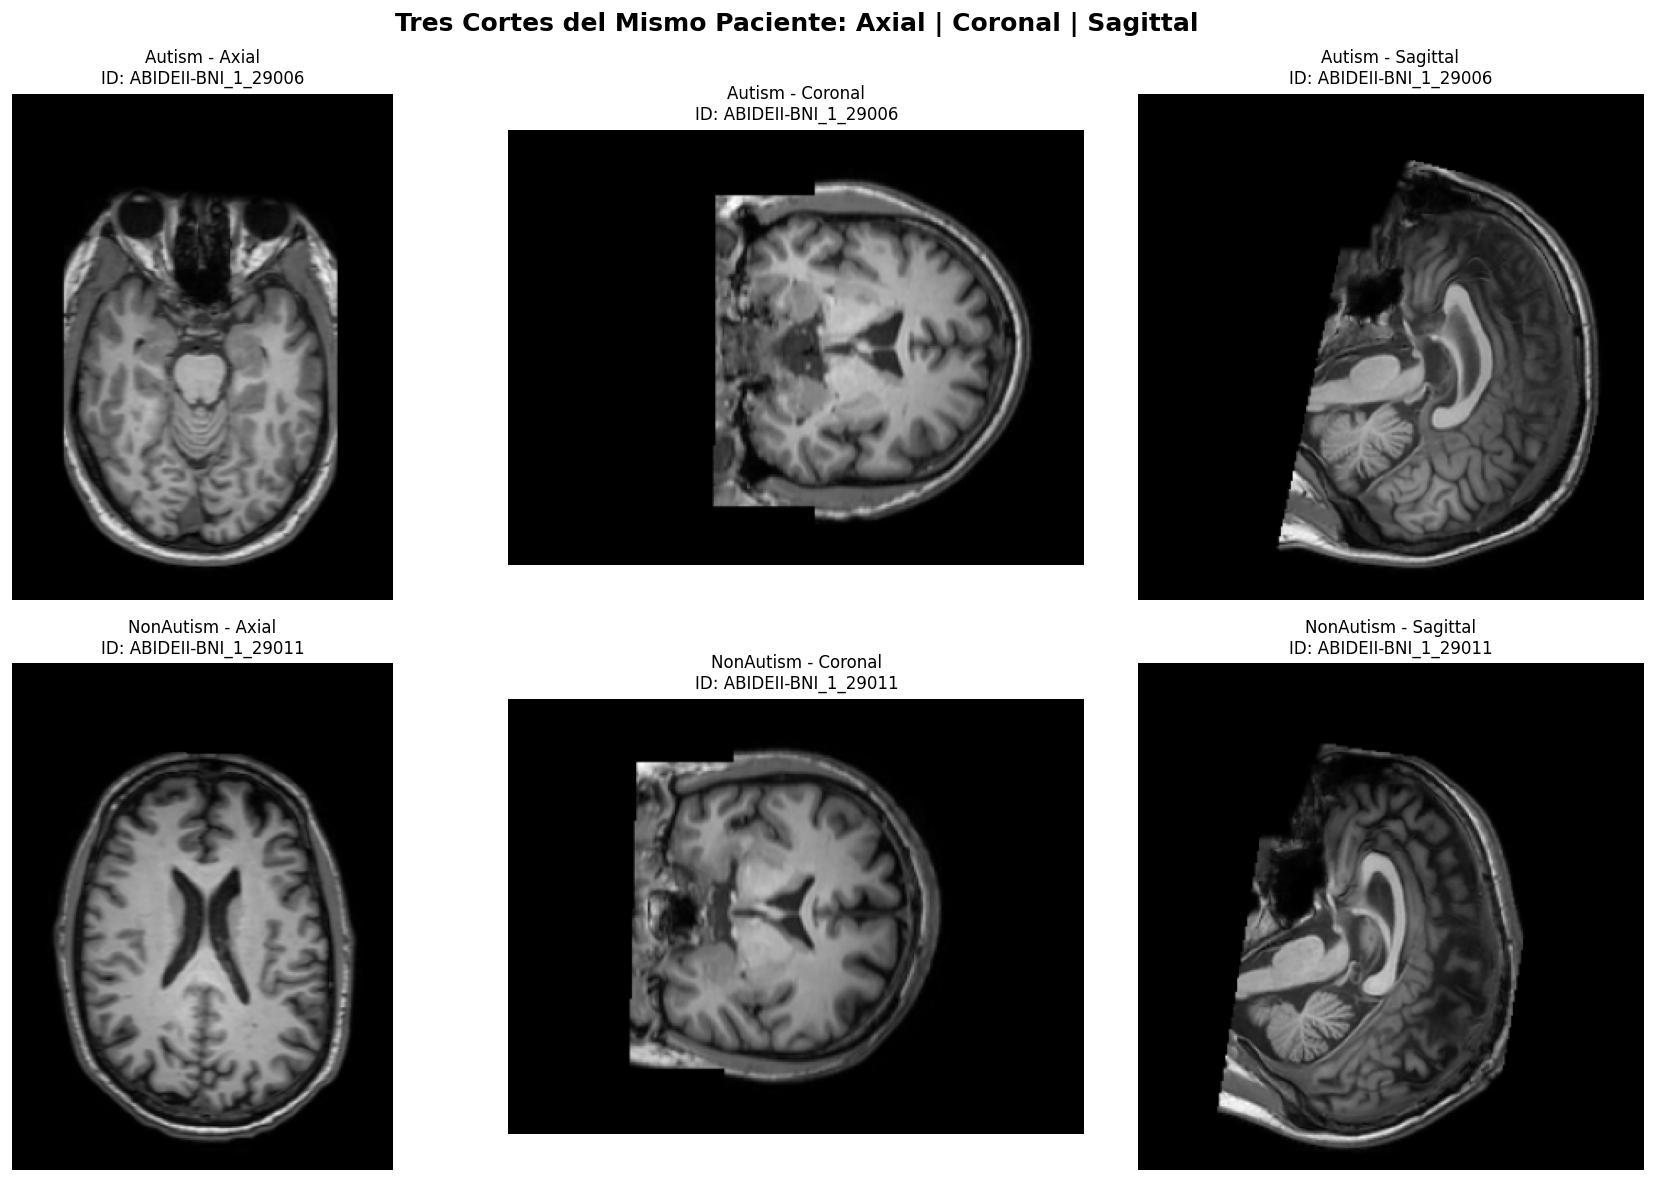

In [17]:
patients_complete = (
    df.groupby(PATIENT_ID_COL)[SLICE_TYPE_COL]
    .nunique()
    .pipe(lambda s: s[s == len(SLICE_TYPES)].index.tolist())
)

print(f'Pacientes con los {len(SLICE_TYPES)} cortes completos: {len(patients_complete):,}')

patients_to_show = {}
for cls_name in CLASS_NAMES:
    candidates = df[
        (df[PATIENT_ID_COL].isin(patients_complete)) & (df[LABEL_COL] == cls_name)
    ][PATIENT_ID_COL].unique()
    if len(candidates) > 0:
        patients_to_show[cls_name] = candidates[0]

n_classes = len(patients_to_show)
fig, axes = plt.subplots(n_classes, len(SLICE_TYPES),
                         figsize=(len(SLICE_TYPES) * 5, n_classes * 5))
if n_classes == 1:
    axes = np.expand_dims(axes, 0)

fig.suptitle('Tres Cortes del Mismo Paciente: Axial | Coronal | Sagittal',
             fontsize=15, fontweight='bold')

for row_i, (cls_name, pid) in enumerate(patients_to_show.items()):
    df_pat = df[df[PATIENT_ID_COL] == pid]
    for col_i, st in enumerate(SLICE_TYPES):
        row_data = df_pat[df_pat[SLICE_TYPE_COL] == st]
        ax = axes[row_i, col_i]
        if len(row_data) > 0:
            try:
                img = decode_image(row_data.iloc[0]['image_bytes'])
                ax.imshow(img)
                ax.set_title(f'{cls_name} - {st.capitalize()}\nID: {pid}', fontsize=10)
                border_color = CLASS_COLORS.get(cls_name, 'gray')
                for spine in ax.spines.values():
                    spine.set_edgecolor(border_color)
                    spine.set_linewidth(4)
                    spine.set_visible(True)
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 13. Analisis de Calidad de Imagen

In [18]:
n_corrupt     = int(df['is_corrupt'].sum())
n_very_dark   = int((df['brightness'] < 10).sum())
n_very_bright = int((df['brightness'] > 245).sum())
n_no_contrast = int((df['contrast'] < 1).sum())
n_diff_res    = int(((df['width'] != most_common_w) | (df['height'] != most_common_h)).sum())

print('=== Diagnostico de Calidad de Imagen ===')
print(f'  Imagenes corruptas              : {n_corrupt:>6,}')
print(f'  Imagenes muy oscuras (bri < 10) : {n_very_dark:>6,}')
print(f'  Imagenes muy claras  (bri > 245): {n_very_bright:>6,}')
print(f'  Sin contraste (std < 1)         : {n_no_contrast:>6,}')
print(f'  Resolucion diferente a dominante: {n_diff_res:>6,}')
print(f"{'─'*50}")
total  = len(df)
issues = n_corrupt + n_very_dark + n_very_bright + n_no_contrast
print(f'  Total imagenes                  : {total:>6,}')
print(f'  Imagenes con problemas (~)      : {issues:>6,}')
print(f'  Tasa de calidad                 : {(1 - issues/total)*100:>5.1f}%')
print(f"{'─'*50}")

=== Diagnostico de Calidad de Imagen ===
  Imagenes corruptas              :      0
  Imagenes muy oscuras (bri < 10) :     16
  Imagenes muy claras  (bri > 245):      0
  Sin contraste (std < 1)         :      0
  Resolucion diferente a dominante:  2,535
──────────────────────────────────────────────────
  Total imagenes                  :  5,835
  Imagenes con problemas (~)      :     16
  Tasa de calidad                 :  99.7%
──────────────────────────────────────────────────


---
## 14. Correlaciones entre Features de Imagen

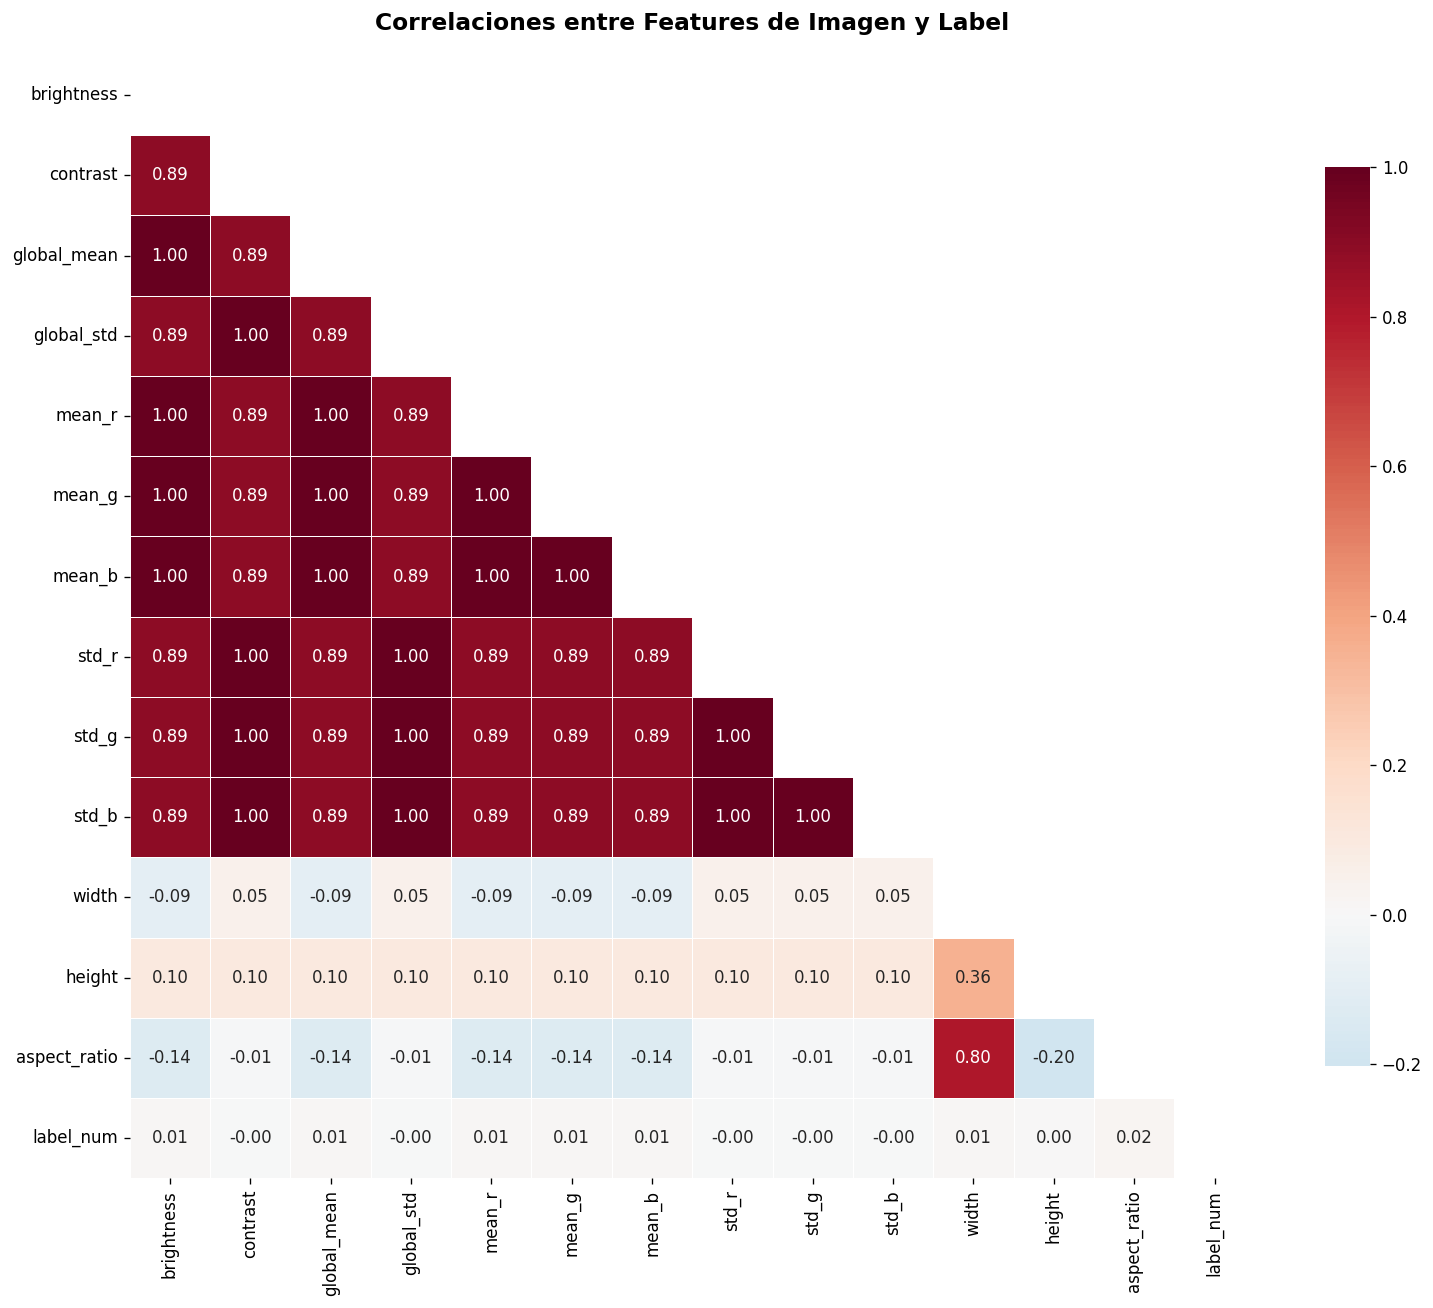


Correlacion absoluta con el label (|r|):
  aspect_ratio       0.0213  
  width              0.0136  
  mean_r             0.0136  
  global_mean        0.0136  
  brightness         0.0136  
  mean_g             0.0136  
  mean_b             0.0136  
  std_g              0.0036  
  contrast           0.0036  
  std_b              0.0036  
  std_r              0.0036  
  global_std         0.0036  
  height             0.0007  


In [21]:
features_corr = [
    'brightness', 'contrast', 'global_mean', 'global_std',
    'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b',
    'width', 'height', 'aspect_ratio',
]

# Mapeo numerico: Autism=1, NonAutism=0
df['label_num']   = df[LABEL_COL].map({'Autism': 1, 'NonAutism': 0})
df_corr_input     = df[features_corr + ['label_num']].dropna()
corr_matrix       = df_corr_input.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlaciones entre Features de Imagen y Label',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

label_corr = corr_matrix['label_num'].drop('label_num').abs().sort_values(ascending=False)
print('\nCorrelacion absoluta con el label (|r|):')
for feat, val in label_corr.items():
    bar = '#' * int(val * 30)
    print(f'  {feat:<18} {val:.4f}  {bar}')

---
## 15. Resumen Final

In [24]:
print('='*68)
print('          RESUMEN FINAL DEL EDA - AUTISM MRI DATASET')
print('='*68)
print(f'  Total registros (imagenes)   : {len(df):>10,}')
print(f'  Total pacientes unicos       : {df[PATIENT_ID_COL].nunique():>10,}')
for st in SLICE_TYPES:
    cnt = int((df[SLICE_TYPE_COL] == st).sum())
    print(f'  Imagenes {st:<12}       : {cnt:>10,}')
print(f'  Clases                       : Autism, NonAutism')
print(f'  Ratio desbalance             : {imbalance:>10.2f}x')
print(f'  Imagenes corruptas           : {n_corrupt:>10,}')
print(f'  Resolucion dominante         : {most_common_w}x{most_common_h} px')

print("""
CONCLUSIONES DEL EDA
--------------------
1. ESTRUCTURA:
   - Cada paciente tiene 3 cortes MRI (axial, coronal, sagittal).
   - La division DEBE realizarse por patient_id para evitar data leakage.
   - La columna image almacena dicts {'bytes': PNG_bytes} (formato HuggingFace).
   - Los labels son 'Autism' y 'NonAutism' (no 'Control').

2. BALANCE DE CLASES:
   - Ver ratio de desbalance en el resumen.
   - Si ratio > 1.5x considerar class_weight o oversampling.

3. CALIDAD DE IMAGEN:
   - Verificar imagenes corruptas/oscuras/sin contraste.
   - Uniformizar resoluciones durante el preprocesamiento.

4. ESTRATEGIA DE MODELADO:
   - Paso 1: 3 modelos baseline independientes (uno por tipo de corte).
   - Paso 2: Modelo multimodal fusionando los 3 cortes por paciente.
   - Backbones recomendados: EfficientNetB0, ResNet18/34, MobileNetV2.

5. METRICAS PRIORITARIAS (por potencial desbalance):
   - ROC-AUC, F1-score (principales)
   - Accuracy, Precision, Recall (secundarias)
""")

          RESUMEN FINAL DEL EDA - AUTISM MRI DATASET
  Total registros (imagenes)   :      5,835
  Total pacientes unicos       :      1,945
  Imagenes axial              :      1,945
  Imagenes coronal            :      1,945
  Imagenes sagittal           :      1,945
  Clases                       : Autism, NonAutism
  Ratio desbalance             :       1.04x
  Imagenes corruptas           :          0
  Resolucion dominante         : 224x224 px

CONCLUSIONES DEL EDA
--------------------
1. ESTRUCTURA:
   - Cada paciente tiene 3 cortes MRI (axial, coronal, sagittal).
   - La division DEBE realizarse por patient_id para evitar data leakage.
   - La columna image almacena dicts {'bytes': PNG_bytes} (formato HuggingFace).
   - Los labels son 'Autism' y 'NonAutism' (no 'Control').

2. BALANCE DE CLASES:
   - Ver ratio de desbalance en el resumen.
   - Si ratio > 1.5x considerar class_weight o oversampling.

3. CALIDAD DE IMAGEN:
   - Verificar imagenes corruptas/oscuras/sin contraste.
